# Final EDA Summary Template

This notebook is a short shared template for final EDA summaries. Each EDA section has three main parts: research question, features/methods, and main findings.

You can copy and paste code from your own notebook into the relevant section to reproduce key tables or plots. This notebook uses a shared `df` dataframe loaded from the cleaned battle stats CSV with all features. If a section needs a different CSV, either modify a copy of `df` or copy the loading cell and change the file path there.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT.name != "summer26-pokemon-battle-predictor" and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"

# Tomorrow, change only this path if everyone is using the same parsed CSV.
PARSED_CSV_PATH = DATA_DIR / "data_cleaned.csv.zip"

print("Project root:", PROJECT_ROOT)
print("Parsed CSV path:", PARSED_CSV_PATH)

Project root: E:\Erdos\Project-Pokemon\summer26-pokemon-battle-predictor
Parsed CSV path: E:\Erdos\Project-Pokemon\summer26-pokemon-battle-predictor\data\data_cleaned.csv.zip


In [2]:
# Load the cleaned csv file.
# Uncomment to load the correct file.

df = pd.read_csv(PARSED_CSV_PATH)
print(df.shape)
df.head()

(12778, 299)


,format,id,p1_win,ratedQ,n_turns,start_time,end_time,duration,p1name,p1side,p1elo0,p1elo1,p2name,p2side,p2elo0,p2elo1,type_diversity_diff,num_boosting_abilities_diff,num_move_boosters_diff,total_stat_diff,p1_total_adv,p1_revealed_team_size,p2_revealed_team_size,M11_name,M11_speciesId,M11_used,M11_gender,M11_shinyQ,M11_level,M11_ability,M11_item,M11_teraType,M11_role,M11_mv1,M11_mv2,M11_mv3,M11_mv4,M11_type1,M11_type2,M11_hp,M11_atk,M11_def,M11_spa,M11_spd,M11_spe,M11_off,M12_name,M12_speciesId,M12_used,M12_gender,...,M24_spa,M24_spd,M24_spe,M24_off,M25_name,M25_speciesId,M25_used,M25_gender,M25_shinyQ,M25_level,M25_ability,M25_item,M25_teraType,M25_role,M25_mv1,M25_mv2,M25_mv3,M25_mv4,M25_type1,M25_type2,M25_hp,M25_atk,M25_def,M25_spa,M25_spd,M25_spe,M25_off,M26_name,M26_speciesId,M26_used,M26_gender,M26_shinyQ,M26_level,M26_ability,M26_item,M26_teraType,M26_role,M26_mv1,M26_mv2,M26_mv3,M26_mv4,M26_type1,M26_type2,M26_hp,M26_atk,M26_def,M26_spa,M26_spd,M26_spe,M26_off
0,gen9randombattle,2642076539,0,True,21,1782884765,1782884937,172,Lirnom,1,1624,1607,Jenome,2,1674,1691,0,0,1,-79,3.125322,4,5,Cyclizar,cyclizar,1,M,False,83,Regenerator,Heavy-Duty Boots,Dragon,Fast Support,taunt,rapidspin,shedtail,dracometeor,Dragon,Normal,252,205,156,189,156,249,205,Cramorant,cramorant,1,M,...,182,118,158,198,Tsareena,tsareena,1,F,False,87,Queenly Majesty,Life Orb,Steel,Fast Support,tripleaxel,synthesis,highjumpkick,powerwhip,Grass,NaN,267,259,220,137,220,175,259,Toxtricity,toxtricity,1,F,False,82,Punk Rock,Choice Specs,Normal,Fast Attacker,sludgewave,boomburst,voltswitch,overdrive,Electric,Poison,257,165,162,234,162,170,234
1,gen9randombattle,2642074504,1,True,7,1782884343,1782884385,42,jnpr010334,1,1651,1667,masajji,2,1582,1566,-1,-1,-2,19,0.997149,2,3,Virizion,virizion,1,N,False,82,Justified,Life Orb,Rock,Setup Sweeper,stoneedge,closecombat,swordsdance,leafblade,Grass,Fighting,283,195,165,195,259,224,195,Koraidon,koraidon,0,N,...,199,141,141,250,Gouging Fire,gougingfire,0,N,False,74,Protosynthesis,Heavy-Duty Boots,Fairy,Bulky Setup,heatcrash,morningsun,outrage,dragondance,Fire,Dragon,277,213,222,139,181,178,213,Zangoose,zangoose,1,M,False,85,Toxic Boost,Toxic Orb,Normal,Fast Attacker,knockoff,facade,swordsdance,closecombat,Normal,NaN,263,244,151,151,151,202,244
2,gen9randombattle,2641921866,1,False,31,1782859109,1782859432,323,realgreenz,1,0,0,ABIDTHEBEST,2,0,0,0,0,1,129,5.479100,6,6,Plusle,plusle,1,M,False,95,Lightning Rod,Life Orb,Fairy,Setup Sweeper,thunderbolt,nastyplot,encore,alluringvoice,Electric,NaN,268,100,130,215,196,234,215,Hatterene,hatterene,1,F,...,188,236,219,188,Passimian,passimian,1,M,False,83,Defiant,Leftovers,Steel,Bulky Setup,gunkshot,bulkup,drainpunch,knockoff,Fighting,NaN,302,247,197,114,147,180,247,Tornadus,tornadus,1,M,False,82,Prankster,Heavy-Duty Boots,Flying,Fast Attacker,nastyplot,bleakwindstorm,grassknot,focusblast,Flying,NaN,264,193,162,252,178,229,252
3,gen9randombattle,2641831207,1,True,51,1782847154,1782847410,256,soumatou_story,1,2113,2127,TheLastOne,2,2014,2000,-2,-2,2,347,3.903277,6,6,Tsareena,tsareena,1,F,False,87,Queenly Majesty,Choice Scarf,Steel,Fast Support,tripleaxel,knockoff,powerwhip,uturn,Grass,NaN,267,259,220,137,220,175,259,Snorlax,snorlax,1,F,...,143,179,270,234,Hitmonchan,hitmonchan,1,M,False,87,Iron Fist,Leftovers,Steel,Bulky Support,encore,drainpunch,knockoff,poisonjab,Fighting,NaN,229,232,187,111,241,182,232,Corviknight,corviknight,1,M,False,80,Mirror Armor,Rocky Helmet,Dragon,Bulky Support,uturn,bodypress,bravebird,roost,Flying,Steel,288,185,214,131,182,153,185
4,gen9randombattle,2642210572,1,True,18,1782911409,1782911669,260,jobzy,1,1177,1201,danbur,2,1165,1141,0,2,1,-120,1.475808,2,6,Dewgong,dewgong,1,M,False,94,Thick Fat,Assault Vest,Poison,Bulky Attacker,knockoff,tripleaxel,surf,flipturn,Water,Ice,322,185,204,185,232,185,185,Iron Boulder,ironboulder,0,N,...,152,170,195,256,Jirachi,jirachi,1,N,False,80,Serene Grace,Leftovers,Water,Fast Support,bodyslam,ironhead,protect,wish,Steel,Psychi

## 1. General Pokemon EDA

### Research Question

- We ask the question: Whether basic Pokemon random team statistics, such as full-team stats, type composition, speed, offensive and defensive strength, have any significant relationships with battle outcomes in Gen 9 random battles?

### Features Looking Into And Methods

- General Pokemon team stats (hp, atk, spa, def, spd, spe) mean max and min.
- Pokemon type and type compositions across team.
- Speed.
- Cross features: offensive and defensive strength.
- Team showups: how many pokemons actually showed up in the battle from both the winner team and the losing team?

### Main Findings

-Basic team-level Pokemon features appear to be highly balanced in Gen 9 random battles. Across 12,778 battles, the average full-team stats are tightly centered, with team mean HP around 278, Attack around 189, Defense around 190, Special Attack around 191, Special Defense around 190, Speed around 181, and mean BST around 1220. Winner-minus-loser differences are extremely small, mostly below 1 stat point on average, and correlations between P1-P2 stat differences and P1 winning are also near zero, with the largest absolute correlation only about 0.028.

-Cross-stat features show the same pattern. Derived features such as physical bulk, special bulk, mixed bulk, best attack, and offensive pressure do not meaningfully separate winners from losers. Most winner-minus-loser differences are close to zero, and the winner-higher percentages stay around 48% to 50%.

-Speed is no longer a deterministic feature in this dataset. Winner and loser teams have almost identical speed summaries: winner mean Speed is about 181.25 and loser mean Speed is about 181.23. Winner max Speed is even slightly lower than loser max Speed by about 0.23 on average, and ranked speed profiles are nearly identical.

-Type composition is also balanced. The most common types are Water, Psychic, Grass, and Flying, but simple type-level win rates stay very close to 50%, roughly between 49.3% and 50.5%. No single type shows a clear dominant advantage from this summary.

-One important bias issue is that not all winning teams reveal or use all 6 Pokemon. Winning teams used/revealed about 4.83 Pokemon on average, and only about 43.7% of winning teams used all 6. This means analyses based only on Pokemon that showed up in battle may undercount the winning team and introduce post-battle selection bias.

-Not all losing teams reveal or use all 6 Pokemon either, though losing teams reveal more Pokemon on average. Losing teams used/revealed about 5.46 Pokemon, and about 75.1% used all 6. Cases where the losing team used very few Pokemon likely reflect early forfeits or disconnected battles. One possible cleaning rule is to flag or remove battles where the losing team used very few Pokemon, for example `n_loser_used <= 2`, to reduce early-forfeit effects.

In [3]:
# General Pokemon EDA setup from the cleaned dataframe.
# This creates analysis-specific copies and does not modify df.

STAT_NAMES = ["hp", "atk", "def", "spa", "spd", "spe"]
AGGS = ["mean", "min", "max"]

eda_df = df.copy()
eda_df["p1_win"] = eda_df["p1_win"].astype(int)

team_rows = []
battle_rows = []
pokemon_rows = []

for _, row in eda_df.iterrows():
    battle_row = {
        "battle_id": row["id"],
        "p1_win": int(row["p1_win"]),
        "n_turns": row.get("n_turns", np.nan),
        "duration": row.get("duration", np.nan),
        "p1_revealed_team_size": row.get("p1_revealed_team_size", np.nan),
        "p2_revealed_team_size": row.get("p2_revealed_team_size", np.nan),
    }

    for side in [1, 2]:
        won = int(row["p1_win"] == 1) if side == 1 else int(row["p1_win"] == 0)
        mons = []
        team_names = []
        type_values = []

        for slot in range(1, 7):
            prefix = f"M{side}{slot}"
            mon = {
                "battle_id": row["id"],
                "side": side,
                "slot": slot,
                "won": won,
                "name": row.get(f"{prefix}_name"),
                "speciesId": row.get(f"{prefix}_speciesId"),
                "used": row.get(f"{prefix}_used"),
                "level": row.get(f"{prefix}_level"),
                "role": row.get(f"{prefix}_role"),
                "item": row.get(f"{prefix}_item"),
                "type1": row.get(f"{prefix}_type1"),
                "type2": row.get(f"{prefix}_type2"),
            }
            for stat in STAT_NAMES:
                mon[stat] = row.get(f"{prefix}_{stat}")
            mon["off"] = row.get(f"{prefix}_off")
            mon["bst"] = sum(mon[stat] for stat in STAT_NAMES if pd.notna(mon[stat]))

            mons.append(mon)
            pokemon_rows.append(mon)
            team_names.append(mon["name"])
            type_values.extend([mon["type1"], mon["type2"]])

        mon_df = pd.DataFrame(mons)
        out = {
            "battle_id": row["id"],
            "side": side,
            "won": won,
            "team": team_names,
            "n_used": mon_df["used"].sum(),
            "type_diversity": pd.Series(type_values).dropna().nunique(),
        }

        for stat in STAT_NAMES:
            out[f"{stat}_mean"] = mon_df[stat].mean()
            out[f"{stat}_min"] = mon_df[stat].min()
            out[f"{stat}_max"] = mon_df[stat].max()

        out["bst_mean"] = mon_df[STAT_NAMES].sum(axis=1).mean()
        out["bst_min"] = mon_df[STAT_NAMES].sum(axis=1).min()
        out["bst_max"] = mon_df[STAT_NAMES].sum(axis=1).max()

        team_rows.append(out)

        p = f"p{side}"
        for key, value in out.items():
            if key not in ["battle_id", "side", "won", "team"]:
                battle_row[f"{p}_{key}"] = value

    battle_rows.append(battle_row)

team_stats_df = pd.DataFrame(team_rows)
battle_stats_df = pd.DataFrame(battle_rows)
pokemon_stats_df = pd.DataFrame(pokemon_rows)

summary_features = [f"{stat}_{agg}" for stat in STAT_NAMES + ["bst"] for agg in AGGS]
for feature in summary_features:
    battle_stats_df[f"diff_{feature}"] = battle_stats_df[f"p1_{feature}"] - battle_stats_df[f"p2_{feature}"]

diff_features = [f"diff_{feature}" for feature in summary_features]
mean_cols = [f"{stat}_mean" for stat in STAT_NAMES]

display(pd.DataFrame({
    "table": ["battle_stats_df", "team_stats_df", "pokemon_stats_df"],
    "rows": [len(battle_stats_df), len(team_stats_df), len(pokemon_stats_df)],
    "columns": [battle_stats_df.shape[1], team_stats_df.shape[1], pokemon_stats_df.shape[1]],
}))

display(battle_stats_df.head())

,table,rows,columns
0,battle_stats_df,12778,73
1,team_stats_df,25556,27
2,pokemon_stats_df,153336,20


,battle_id,p1_win,n_turns,duration,p1_revealed_team_size,p2_revealed_team_size,p1_n_used,p1_type_diversity,p1_hp_mean,p1_hp_min,p1_hp_max,p1_atk_mean,p1_atk_min,p1_atk_max,p1_def_mean,p1_def_min,p1_def_max,p1_spa_mean,p1_spa_min,p1_spa_max,p1_spd_mean,p1_spd_min,p1_spd_max,p1_spe_mean,p1_spe_min,p1_spe_max,p1_bst_mean,p1_bst_min,p1_bst_max,p2_n_used,p2_type_diversity,p2_hp_mean,p2_hp_min,p2_hp_max,p2_atk_mean,p2_atk_min,p2_atk_max,p2_def_mean,p2_def_min,p2_def_max,p2_spa_mean,p2_spa_min,p2_spa_max,p2_spd_mean,p2_spd_min,p2_spd_max,p2_spe_mean,p2_spe_min,p2_spe_max,p2_bst_mean,p2_bst_min,p2_bst_max,diff_hp_mean,diff_hp_min,diff_hp_max,diff_atk_mean,diff_atk_min,diff_atk_max,diff_def_mean,diff_def_min,diff_def_max,diff_spa_mean,diff_spa_min,diff_spa_max,diff_spd_mean,diff_spd_min,diff_spd_max,diff_spe_mean,diff_spe_min,diff_spe_max,diff_bst_mean,diff_bst_min,diff_bst_max
0,2642076539,0,21,172,4,5,4,8,273.500000,252,302,194.333333,90,255,181.333333,144,214,169.666667,139,199,174.833333,142,213,195.833333,106,249,1189.500000,1131,1208,5,8,267.166667,211,297,198.166667,165,259,219.833333,162,334,187.000000,137,234,178.166667,118,220,170.333333,107,206,1220.666667,1100,1321,6.333333,41,5,-3.833333,-75,-4,-38.500000,-18,-120,-17.333333,2,-35,-3.333333,24,-7,25.500000,-1,43,-31.166667,31,-113
1,2642074504,1,7,42,2,3,2,6,278.666667,235,326,188.166667,164,211,188.333333,150,244,189.166667,142,251,191.166667,142,259,186.833333,121,224,1222.333333,1131,1321,3,7,269.333333,243,309,208.666667,137,250,213.000000,151,297,186.333333,139,221,186.833333,141,267,157.000000,85,208,1221.166667,1162,1349,9.333333,-8,17,-20.500000,27,-39,-24.666667,-1,-53,2.833333,3,30,4.333333,1,-8,29.833333,36,16,1.166667,-31,-28
2,2641921866,1,31,323,6,6,6,7,265.666667,231,321,188.000000,100,258,189.666667,130,244,193.333333,144,280,201.333333,128,267,184.833333,98,267,1222.833333,1143,1295,6,7,271.333333,225,302,176.666667,93,247,189.833333,152,247,207.333333,114,252,180.833333,147,236,182.333333,113,229,1208.333333,1163,1278,-5.666667,6,19,11.333333,7,11,-0.166667,-22,-3,-14.000000,30,28,20.500000,-19,31,2.500000,-15,38,14.500000,-20,17
3,2641831207,1,51,256,6,6,6,6,296.166667,256,397,208.333333,97,259,192.500000,145,251,204.666667,137,273,201.500000,183,228,163.833333,96,208,1267.000000,1156,1311,6,8,265.666667,212,305,198.333333,91,234,166.833333,131,214,171.500000,111,236,199.166667,131,304,196.333333,153,270,1197.833333,1013,1404,30.500000,44,92,10.000000,6,25,25.666667,14,37,33.166667,26,37,2.333333,52,-76,-32.500000,-57,-62,69.166667,143,-93
4,2642210572,1,18,260,2,6,2,8,277.833333,259,322,199.833333,96,254,197.666667,151,244,187.166667,149,261,203.333333,151,234,169.333333,86,236,1235.166667,1162,1313,6,8,267.333333,245,291,201.000000,142,256,198.000000,169,240,195.166667,142,254,206.833333,170,240,192.166667,169,222,1260.500000,1217,1321,10.500000,14,31,-1.166667,-46,-2,-0.333333,-18,4,-8.000000,7,7,-3.500000,-19,-6,-22.833333,-83,14,-25.333333,-55,-8


In [4]:
# Basic dataset overview for the cleaned data version.

overview = pd.Series({
    "n_battles": len(eda_df),
    "p1_win_rate": eda_df["p1_win"].mean(),
    "rated_battle_rate": eda_df["ratedQ"].mean() if "ratedQ" in eda_df else np.nan,
    "mean_turns": eda_df["n_turns"].mean() if "n_turns" in eda_df else np.nan,
    "median_turns": eda_df["n_turns"].median() if "n_turns" in eda_df else np.nan,
    "mean_duration": eda_df["duration"].mean() if "duration" in eda_df else np.nan,
    "median_duration": eda_df["duration"].median() if "duration" in eda_df else np.nan,
})

display(overview.to_frame("value"))
display(team_stats_df[summary_features + ["n_used", "type_diversity"]].describe().T)

,value
n_battles,12778.000000
p1_win_rate,0.478009
rated_battle_rate,0.551730
mean_turns,24.749961
median_turns,24.000000
mean_duration,302.380733
median_duration,278.000000


,count,mean,std,min,25%,50%,75%,max
hp_mean,25556.0,278.273269,16.916849,230.833333,266.666667,276.166667,287.166667,389.666667
hp_min,25556.0,237.978713,17.289074,191.000000,225.000000,240.000000,249.000000,308.000000
hp_max,25556.0,335.506809,56.570941,252.000000,302.000000,321.000000,352.000000,572.000000
atk_mean,25556.0,189.378261,22.198284,109.666667,174.500000,189.833333,204.500000,273.833333
atk_min,25556.0,116.390476,32.351055,13.000000,97.000000,114.000000,133.000000,247.000000
atk_max,25556.0,254.455705,26.280532,115.000000,238.000000,255.000000,267.000000,348.000000
def_mean,25556.0,190.344029,16.774867,134.166667,178.666667,189.166667,200.833333,273.333333
def_min,25556.0,146.274495,21.983197,57.000000,139.000000,148.000000,159.000000,224.000000
def_max,25556.0,249.191697,42.699497,159.000000,218.000000,244.000000,270.000000,383.000000
spa_mean,25556.0,190.647154,18.250717,123.166667,178.000000,190.500000,203.333333,257.166667


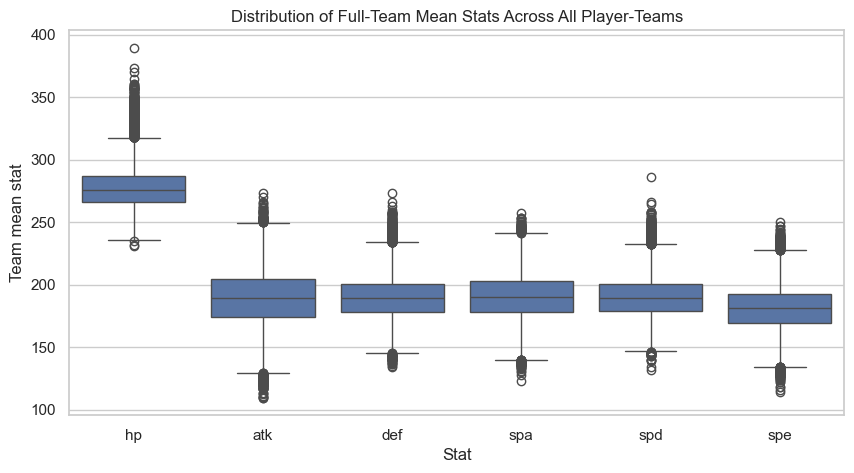

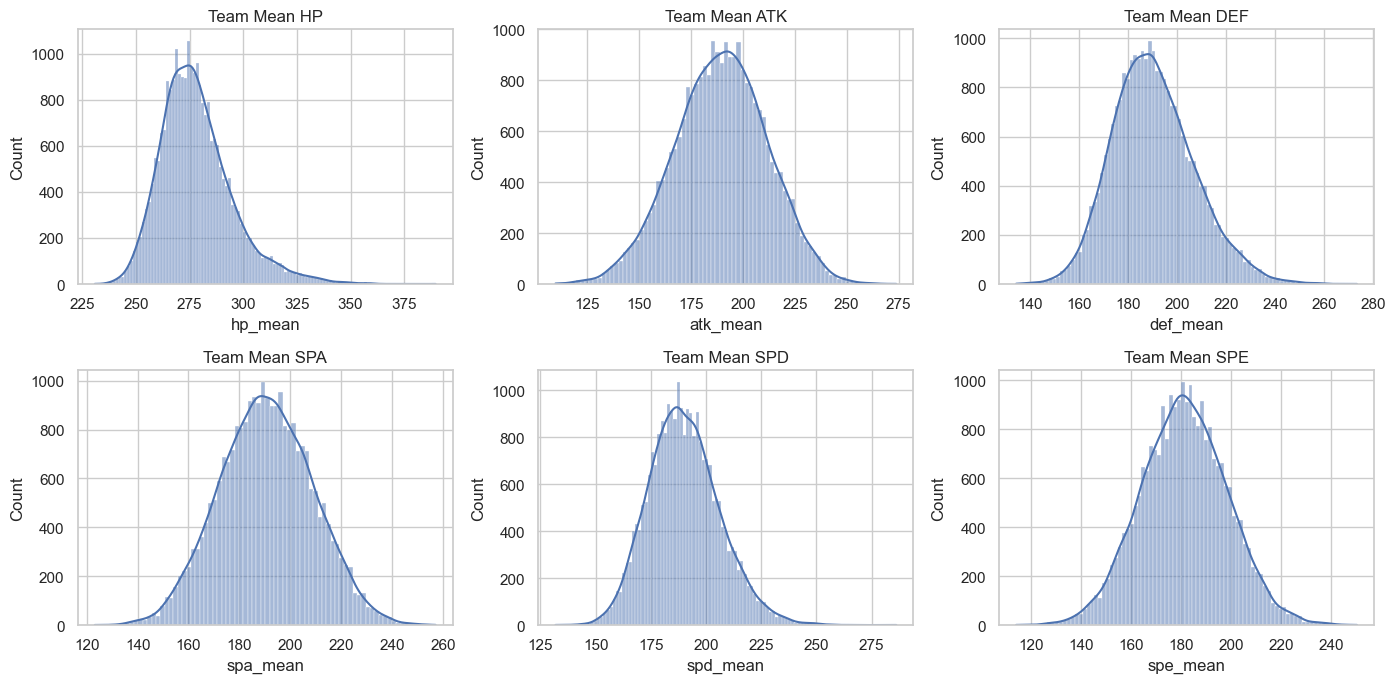

In [5]:
# Distribution of full-team mean stats across all player-teams.

team_stats_long = team_stats_df.melt(
    id_vars=["battle_id", "side", "won"],
    value_vars=mean_cols,
    var_name="stat",
    value_name="value",
)
team_stats_long["stat"] = team_stats_long["stat"].str.replace("_mean", "", regex=False)

plt.figure(figsize=(10, 5))
sns.boxplot(data=team_stats_long, x="stat", y="value")
plt.title("Distribution of Full-Team Mean Stats Across All Player-Teams")
plt.xlabel("Stat")
plt.ylabel("Team mean stat")
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.ravel()
for ax, stat in zip(axes, STAT_NAMES):
    col = f"{stat}_mean"
    sns.histplot(team_stats_df[col], kde=True, ax=ax)
    ax.set_title(f"Team Mean {stat.upper()}")
    ax.set_xlabel(col)
plt.tight_layout()
plt.show()

In [6]:
# Winner vs loser full-team stat summary.

winner_loser_summary = (
    team_stats_df
    .groupby("won")[summary_features]
    .mean()
    .T
    .rename(columns={0: "losing_teams", 1: "winning_teams"})
)
winner_loser_summary["winner_minus_loser"] = (
    winner_loser_summary["winning_teams"] - winner_loser_summary["losing_teams"]
)

winner_loser_summary.sort_values("winner_minus_loser", ascending=False)

won,losing_teams,winning_teams,winner_minus_loser
def_max,248.809438,249.573955,0.764517
def_min,146.052043,146.496948,0.444905
def_mean,190.168767,190.519291,0.350524
spd_min,146.541478,146.815386,0.273908
spa_min,133.545156,133.740726,0.195571
atk_min,116.305995,116.474957,0.168962
spd_mean,190.176514,190.305238,0.128724
spa_mean,190.625046,190.669262,0.044217
spe_mean,181.225440,181.251291,0.025852
spe_min,126.667006,126.646658,-0.020347


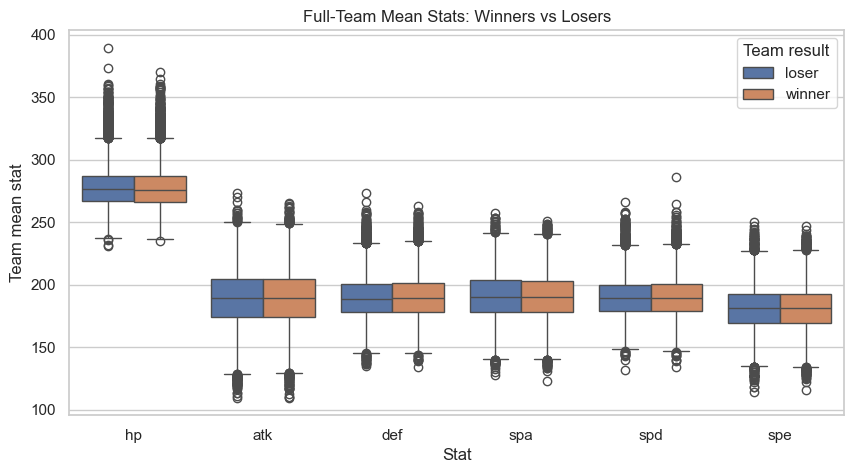

In [7]:
# Full-team mean stats by battle outcome.

team_win_long = team_stats_df.melt(
    id_vars=["won"],
    value_vars=mean_cols,
    var_name="stat",
    value_name="value",
)
team_win_long["stat"] = team_win_long["stat"].str.replace("_mean", "", regex=False)
team_win_long["team_result"] = np.where(team_win_long["won"] == 1, "winner", "loser")

plt.figure(figsize=(10, 5))
sns.boxplot(data=team_win_long, x="stat", y="value", hue="team_result")
plt.title("Full-Team Mean Stats: Winners vs Losers")
plt.xlabel("Stat")
plt.ylabel("Team mean stat")
plt.legend(title="Team result")
plt.show()

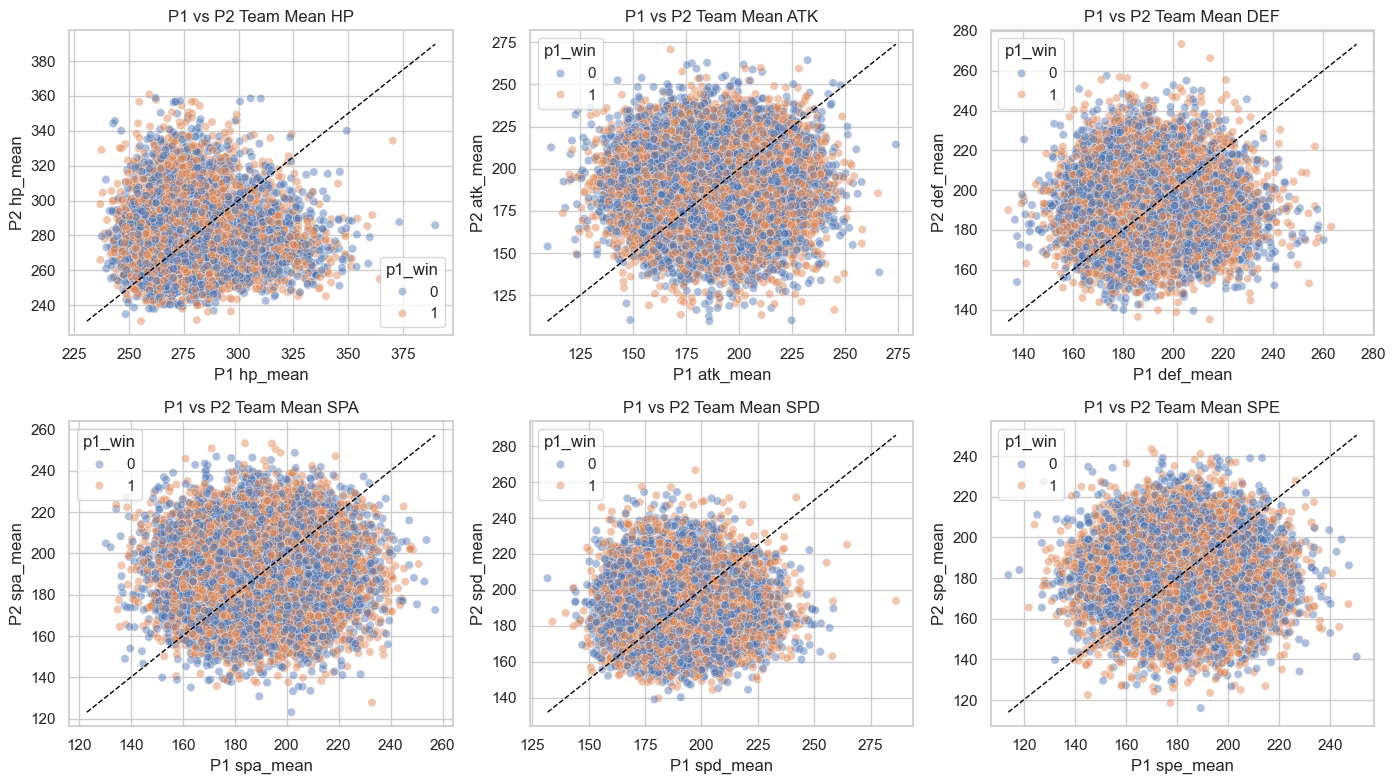

In [8]:
# P1 vs P2 team mean stats by battle outcome.

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

for ax, stat in zip(axes, STAT_NAMES):
    col = f"{stat}_mean"
    x_col = f"p1_{col}"
    y_col = f"p2_{col}"
    sns.scatterplot(
        data=battle_stats_df,
        x=x_col,
        y=y_col,
        hue="p1_win",
        alpha=0.45,
        ax=ax,
    )
    min_val = min(battle_stats_df[x_col].min(), battle_stats_df[y_col].min())
    max_val = max(battle_stats_df[x_col].max(), battle_stats_df[y_col].max())
    ax.plot([min_val, max_val], [min_val, max_val], color="black", linestyle="--", linewidth=1)
    ax.set_title(f"P1 vs P2 Team Mean {stat.upper()}")
    ax.set_xlabel(f"P1 {col}")
    ax.set_ylabel(f"P2 {col}")

plt.tight_layout()
plt.show()

,corr_with_p1_win
diff_hp_max,-0.028361
diff_hp_mean,-0.026585
diff_def_mean,0.014813
diff_def_min,0.014075
diff_def_max,0.012853
diff_spd_min,0.011467
diff_bst_max,-0.008642
diff_hp_min,-0.007030
diff_spa_min,0.006847
diff_atk_max,-0.006162


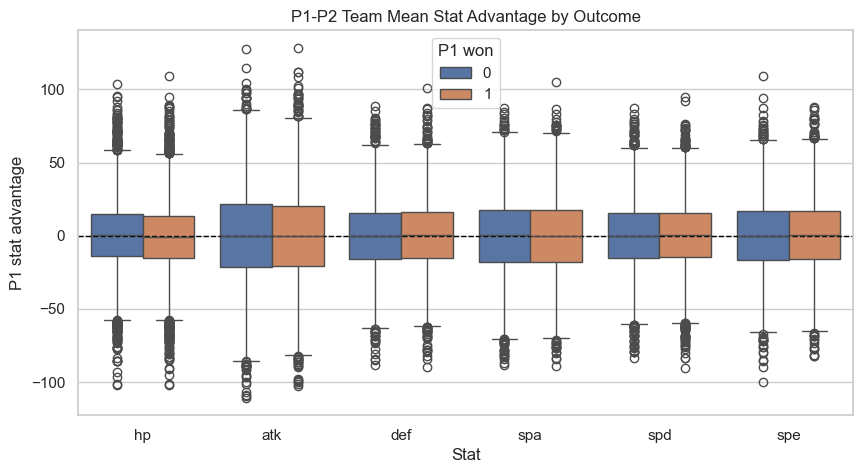

In [9]:
# Correlation between P1-P2 team stat differences and P1 winning.

corrs = (
    battle_stats_df[diff_features + ["p1_win"]]
    .corr(numeric_only=True)["p1_win"]
    .drop("p1_win")
    .sort_values(key=abs, ascending=False)
)

display(corrs.to_frame("corr_with_p1_win"))

# Plot P1-P2 mean stat advantages by outcome.
diff_mean_cols = [f"diff_{stat}_mean" for stat in STAT_NAMES]
diff_long = battle_stats_df.melt(
    id_vars=["p1_win"],
    value_vars=diff_mean_cols,
    var_name="stat_diff",
    value_name="p1_minus_p2",
)
diff_long["stat"] = (
    diff_long["stat_diff"]
    .str.replace("diff_", "", regex=False)
    .str.replace("_mean", "", regex=False)
)

plt.figure(figsize=(10, 5))
sns.boxplot(data=diff_long, x="stat", y="p1_minus_p2", hue="p1_win")
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("P1-P2 Team Mean Stat Advantage by Outcome")
plt.xlabel("Stat")
plt.ylabel("P1 stat advantage")
plt.legend(title="P1 won")
plt.show()

,stat,advantage_bin,p1_win_rate,n
0,hp,"(-102.001, -18.667]",0.493952,2563
1,hp,"(-18.667, -5.5]",0.495693,2554
2,hp,"(-5.5, 5.0]",0.479077,2557
3,hp,"(5.0, 18.167]",0.471188,2551
4,hp,"(18.167, 109.333]",0.450059,2553
5,atk,"(-110.834, -26.333]",0.466823,2562
6,atk,"(-26.333, -8.0]",0.493390,2572
7,atk,"(-8.0, 8.0]",0.472899,2546
8,atk,"(8.0, 26.333]",0.490366,2543
9,atk,"(26.333, 128.5]",0.466536,2555


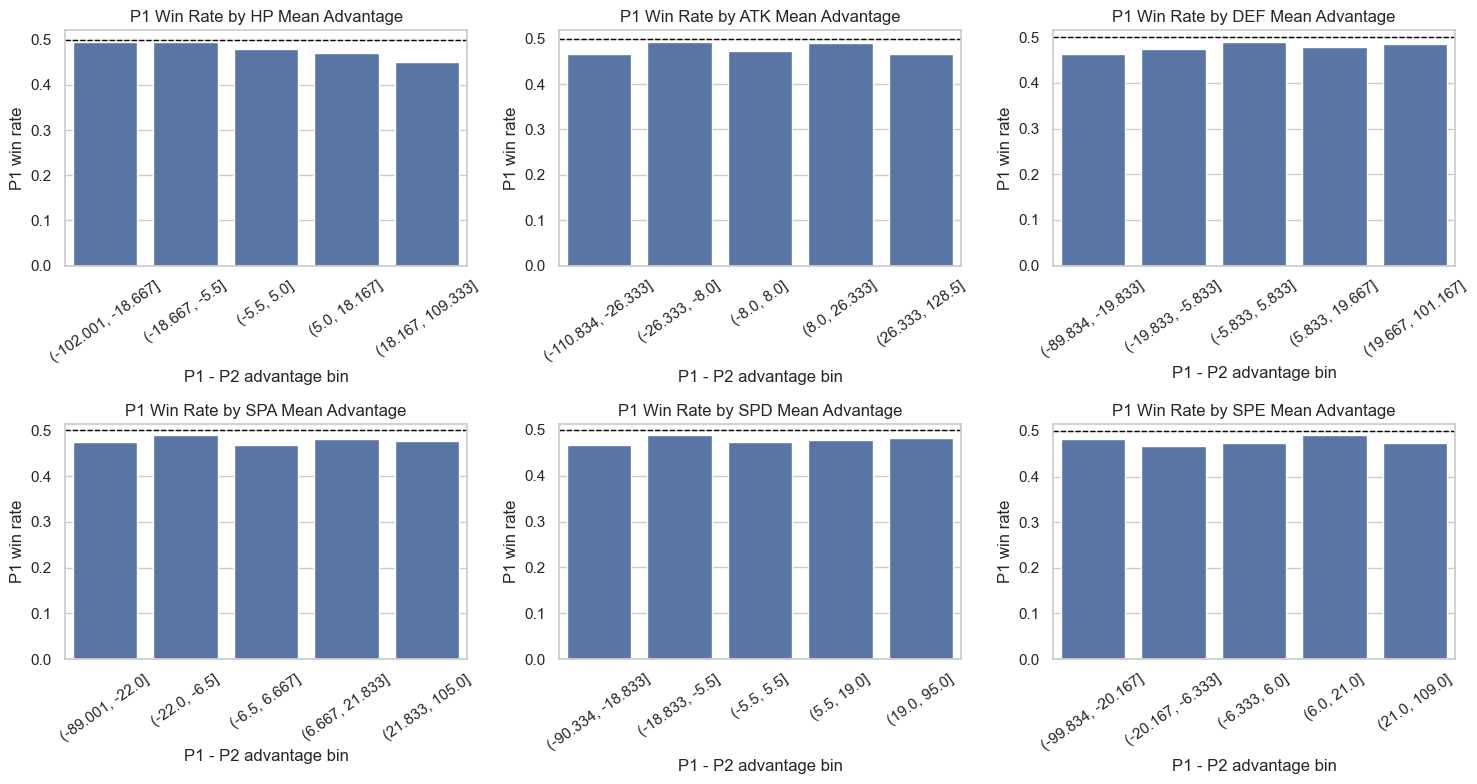

In [10]:
# P1 win rate by binned stat advantages.

def win_rate_by_advantage(source_df, diff_col, q=5):
    temp = source_df[[diff_col, "p1_win"]].dropna().copy()
    temp["advantage_bin"] = pd.qcut(temp[diff_col], q=q, duplicates="drop")
    return (
        temp
        .groupby("advantage_bin", observed=True)["p1_win"]
        .agg(p1_win_rate="mean", n="count")
        .reset_index()
    )

win_rate_tables = []
for stat in STAT_NAMES:
    table = win_rate_by_advantage(battle_stats_df, f"diff_{stat}_mean")
    table.insert(0, "stat", stat)
    win_rate_tables.append(table)

stat_advantage_win_rate_df = pd.concat(win_rate_tables, ignore_index=True)
display(stat_advantage_win_rate_df)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()
for ax, stat in zip(axes, STAT_NAMES):
    plot_df = stat_advantage_win_rate_df[stat_advantage_win_rate_df["stat"] == stat].copy()
    plot_df["bin_label"] = plot_df["advantage_bin"].astype(str)
    sns.barplot(data=plot_df, x="bin_label", y="p1_win_rate", ax=ax)
    ax.axhline(0.5, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"P1 Win Rate by {stat.upper()} Mean Advantage")
    ax.set_xlabel("P1 - P2 advantage bin")
    ax.set_ylabel("P1 win rate")
    ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()

,type,count,pct_of_type_slots
0,Water,21620,0.088283
1,Psychic,19211,0.078447
2,Grass,16773,0.068491
3,Flying,16557,0.067609
4,Normal,16047,0.065527
5,Fighting,15910,0.064967
6,Dark,14278,0.058303
7,Dragon,13988,0.057119
8,Electric,12762,0.052113
9,Fire,12564,0.051304


,type,appearances,win_rate
17,Water,21620,0.498936
14,Psychic,19211,0.492895
9,Grass,16773,0.501401
7,Flying,16557,0.495319
12,Normal,16047,0.495295
5,Fighting,15910,0.504085
1,Dark,14278,0.497269
2,Dragon,13988,0.501072
3,Electric,12762,0.504388
6,Fire,12564,0.498727


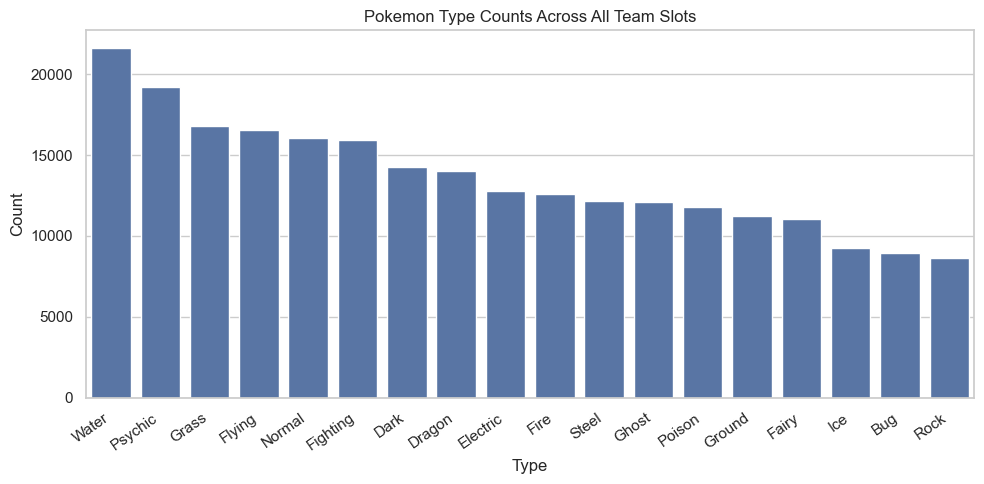

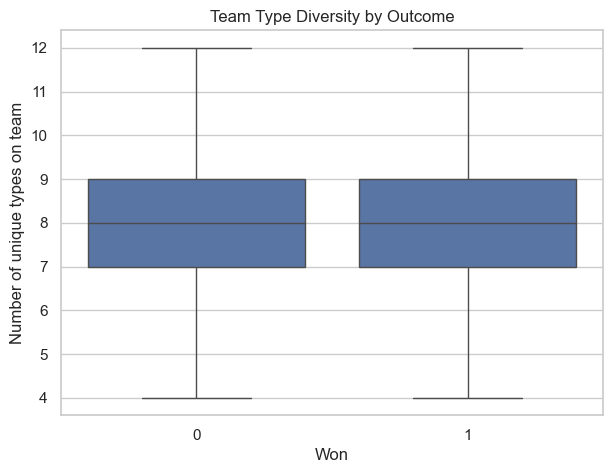

In [11]:
# Type distribution and type diversity.

type_long = pokemon_stats_df.melt(
    id_vars=["battle_id", "side", "slot", "won", "name"],
    value_vars=["type1", "type2"],
    var_name="type_slot",
    value_name="type",
).dropna(subset=["type"])

type_counts = (
    type_long["type"]
    .value_counts()
    .rename_axis("type")
    .reset_index(name="count")
)
type_counts["pct_of_type_slots"] = type_counts["count"] / type_counts["count"].sum()

display(type_counts)

type_win_summary = (
    type_long
    .groupby("type")
    .agg(
        appearances=("type", "size"),
        win_rate=("won", "mean"),
    )
    .reset_index()
    .sort_values("appearances", ascending=False)
)
display(type_win_summary)

plt.figure(figsize=(10, 5))
sns.barplot(data=type_counts, x="type", y="count")
plt.title("Pokemon Type Counts Across All Team Slots")
plt.xlabel("Type")
plt.ylabel("Count")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
sns.boxplot(data=team_stats_df, x="won", y="type_diversity")
plt.title("Team Type Diversity by Outcome")
plt.xlabel("Won")
plt.ylabel("Number of unique types on team")
plt.show()

,mean,median,min,max,count
won,,,,,
losing_teams,5.464548,6.0,0,6,12778
winning_teams,4.826812,5.0,0,6,12778


,won,n_used,proportion
0,0,6,0.751448
1,0,5,0.104320
2,0,4,0.062138
3,0,3,0.040225
4,0,2,0.023321
5,0,1,0.018391
6,0,0,0.000157
7,1,6,0.437314
8,1,5,0.257474
9,1,4,0.136641


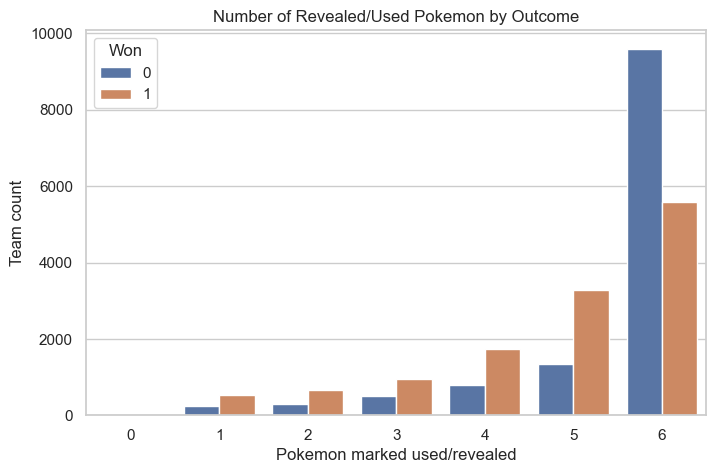

In [12]:
# Revealed / used Pokemon counts by outcome.
# This is useful because revealed Pokemon are affected by battle progression and can introduce post-battle bias.

revealed_summary = (
    team_stats_df
    .groupby("won")["n_used"]
    .agg(mean="mean", median="median", min="min", max="max", count="count")
    .rename(index={0: "losing_teams", 1: "winning_teams"})
)
display(revealed_summary)

display(
    team_stats_df
    .groupby("won")["n_used"]
    .value_counts(normalize=True)
    .rename("proportion")
    .reset_index()
)

plt.figure(figsize=(8, 5))
sns.countplot(data=team_stats_df, x="n_used", hue="won")
plt.title("Number of Revealed/Used Pokemon by Outcome")
plt.xlabel("Pokemon marked used/revealed")
plt.ylabel("Team count")
plt.legend(title="Won")
plt.show()

,mean,median,std,min,max
abs_diff_hp_max,54.071999,35.000000,58.802921,0.0,309.000000
abs_diff_def_max,46.811942,38.000000,38.397232,0.0,207.000000
abs_diff_spd_max,40.102050,31.000000,34.915079,0.0,238.000000
abs_diff_atk_min,33.850759,24.000000,30.662817,0.0,211.000000
abs_diff_spe_max,29.360463,21.000000,29.420539,0.0,196.000000
abs_diff_atk_max,28.295821,22.000000,24.309875,0.0,186.000000
abs_diff_spe_min,27.979496,24.000000,20.927897,0.0,135.000000
abs_diff_spa_max,26.599311,22.000000,20.920985,0.0,154.000000
abs_diff_atk_mean,24.971840,21.000000,18.831907,0.0,128.500000
abs_diff_spa_min,24.727735,20.000000,19.413406,0.0,131.000000


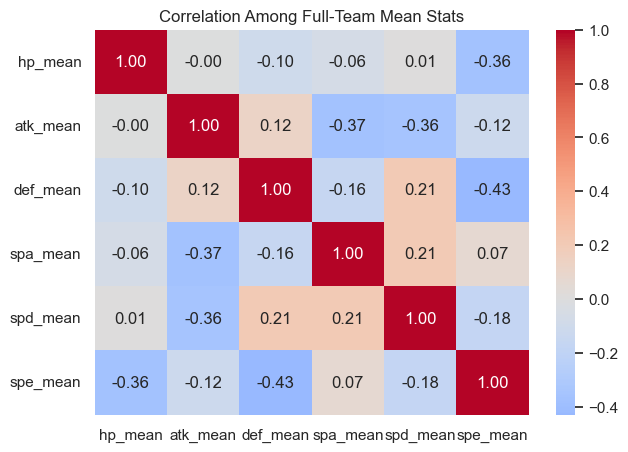

In [13]:
# Full-team balance: absolute P1-P2 stat differences within each battle.

balance_cols = []
for stat in STAT_NAMES:
    for agg in AGGS:
        col = f"abs_diff_{stat}_{agg}"
        battle_stats_df[col] = (battle_stats_df[f"p1_{stat}_{agg}"] - battle_stats_df[f"p2_{stat}_{agg}"]).abs()
        balance_cols.append(col)

balance_summary = (
    battle_stats_df[balance_cols]
    .agg(["mean", "median", "std", "min", "max"])
    .T
    .sort_values("mean", ascending=False)
)

display(balance_summary)

plt.figure(figsize=(7, 5))
sns.heatmap(
    team_stats_df[mean_cols].corr(),
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
)
plt.title("Correlation Among Full-Team Mean Stats")
plt.show()

In [14]:
# Speed analysis: winner vs loser full-team speed min/mean/max and ranked speed profile.

speed_rows = []
for battle_id, group in team_stats_df.groupby("battle_id"):
    if len(group) != 2:
        continue
    winner = group[group["won"] == 1].iloc[0]
    loser = group[group["won"] == 0].iloc[0]

    original_row = eda_df.loc[eda_df["id"] == battle_id].iloc[0]
    winner_side = int(winner["side"])
    loser_side = int(loser["side"])

    winner_speeds = sorted([original_row[f"M{winner_side}{i}_spe"] for i in range(1, 7)], reverse=True)
    loser_speeds = sorted([original_row[f"M{loser_side}{i}_spe"] for i in range(1, 7)], reverse=True)

    out = {
        "battle_id": battle_id,
        "winner_spe_min": min(winner_speeds),
        "winner_spe_mean": np.mean(winner_speeds),
        "winner_spe_max": max(winner_speeds),
        "loser_spe_min": min(loser_speeds),
        "loser_spe_mean": np.mean(loser_speeds),
        "loser_spe_max": max(loser_speeds),
        "diff_spe_min": min(winner_speeds) - min(loser_speeds),
        "diff_spe_mean": np.mean(winner_speeds) - np.mean(loser_speeds),
        "diff_spe_max": max(winner_speeds) - max(loser_speeds),
    }
    for rank in range(1, 7):
        out[f"winner_spe_rank_{rank}"] = winner_speeds[rank - 1]
        out[f"loser_spe_rank_{rank}"] = loser_speeds[rank - 1]
        out[f"diff_spe_rank_{rank}"] = winner_speeds[rank - 1] - loser_speeds[rank - 1]
    speed_rows.append(out)

speed_eda_df = pd.DataFrame(speed_rows)

speed_summary_rows = []
for feature in ["spe_min", "spe_mean", "spe_max"]:
    diff_col = f"diff_{feature}"
    speed_summary_rows.append({
        "feature": feature,
        "winner_mean": speed_eda_df[f"winner_{feature}"].mean(),
        "loser_mean": speed_eda_df[f"loser_{feature}"].mean(),
        "winner_minus_loser_mean": speed_eda_df[diff_col].mean(),
        "winner_minus_loser_median": speed_eda_df[diff_col].median(),
        "winner_higher_pct": (speed_eda_df[diff_col] > 0).mean(),
        "tie_pct": (speed_eda_df[diff_col] == 0).mean(),
        "loser_higher_pct": (speed_eda_df[diff_col] < 0).mean(),
    })

speed_min_mean_max_summary = pd.DataFrame(speed_summary_rows)
display(speed_min_mean_max_summary)

speed_rank_summary_rows = []
for rank in range(1, 7):
    diff_col = f"diff_spe_rank_{rank}"
    speed_rank_summary_rows.append({
        "speed_rank": rank,
        "winner_mean": speed_eda_df[f"winner_spe_rank_{rank}"].mean(),
        "loser_mean": speed_eda_df[f"loser_spe_rank_{rank}"].mean(),
        "winner_minus_loser_mean": speed_eda_df[diff_col].mean(),
        "winner_minus_loser_median": speed_eda_df[diff_col].median(),
        "winner_higher_pct": (speed_eda_df[diff_col] > 0).mean(),
        "tie_pct": (speed_eda_df[diff_col] == 0).mean(),
        "loser_higher_pct": (speed_eda_df[diff_col] < 0).mean(),
    })
speed_rank_summary = pd.DataFrame(speed_rank_summary_rows)
display(speed_rank_summary)

,feature,winner_mean,loser_mean,winner_minus_loser_mean,winner_minus_loser_median,winner_higher_pct,tie_pct,loser_higher_pct
0,spe_min,126.646658,126.667006,-0.020347,0.000000,0.488887,0.019017,0.492096
1,spe_mean,181.251291,181.225440,0.025852,0.166667,0.501565,0.002817,0.495617
2,spe_max,234.132885,234.359681,-0.226796,0.000000,0.496400,0.019721,0.483879


,speed_rank,winner_mean,loser_mean,winner_minus_loser_mean,winner_minus_loser_median,winner_higher_pct,tie_pct,loser_higher_pct
0,1,234.132885,234.359681,-0.226796,0.0,0.496400,0.019721,0.483879
1,2,209.189310,208.988105,0.201205,0.0,0.496948,0.016591,0.486461
2,3,191.220222,190.881359,0.338864,0.0,0.499139,0.016513,0.484348
3,4,173.188214,173.227970,-0.039756,0.0,0.497339,0.017295,0.485365
4,5,153.130459,153.228518,-0.098059,0.0,0.490139,0.016904,0.492957
5,6,126.646658,126.667006,-0.020347,0.0,0.488887,0.019017,0.492096


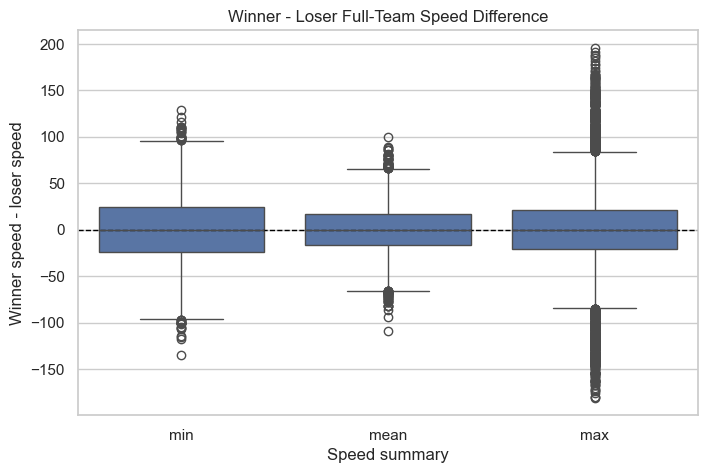

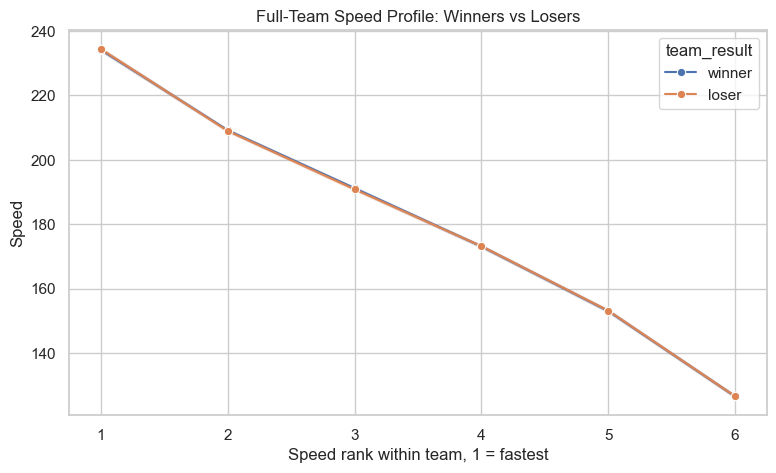

In [15]:
# Speed plots.

speed_min_mean_max_long = speed_eda_df.melt(
    value_vars=["diff_spe_min", "diff_spe_mean", "diff_spe_max"],
    var_name="speed_feature",
    value_name="winner_minus_loser",
)
speed_min_mean_max_long["speed_feature"] = speed_min_mean_max_long["speed_feature"].str.replace("diff_spe_", "", regex=False)

plt.figure(figsize=(8, 5))
sns.boxplot(data=speed_min_mean_max_long, x="speed_feature", y="winner_minus_loser")
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Winner - Loser Full-Team Speed Difference")
plt.xlabel("Speed summary")
plt.ylabel("Winner speed - loser speed")
plt.show()

speed_rank_long_rows = []
for _, row in speed_eda_df.iterrows():
    for rank in range(1, 7):
        speed_rank_long_rows.append({"battle_id": row["battle_id"], "rank": rank, "team_result": "winner", "speed": row[f"winner_spe_rank_{rank}"]})
        speed_rank_long_rows.append({"battle_id": row["battle_id"], "rank": rank, "team_result": "loser", "speed": row[f"loser_spe_rank_{rank}"]})
speed_rank_long = pd.DataFrame(speed_rank_long_rows)

plt.figure(figsize=(9, 5))
sns.lineplot(data=speed_rank_long, x="rank", y="speed", hue="team_result", marker="o", errorbar=("ci", 95))
plt.title("Full-Team Speed Profile: Winners vs Losers")
plt.xlabel("Speed rank within team, 1 = fastest")
plt.ylabel("Speed")
plt.xticks(range(1, 7))
plt.show()

In [16]:
# Derived team stats: bulk and offensive pressure.

derived_defs = {
    "physical_bulk": lambda m: m["hp"] + m["def"],
    "special_bulk": lambda m: m["hp"] + m["spd"],
    "mixed_bulk": lambda m: m["hp"] + m["def"] + m["spd"],
    "best_attack": lambda m: max(m["atk"], m["spa"]),
    "offensive_pressure": lambda m: max(m["atk"], m["spa"]) + m["spe"],
}

derived_rows = []
for battle_id, side_group in pokemon_stats_df.groupby(["battle_id", "side"]):
    battle_id_value, side = battle_id
    won = int(side_group["won"].iloc[0])
    out = {"battle_id": battle_id_value, "side": side, "won": won}

    mons = side_group[STAT_NAMES].to_dict("records")
    for feature, func in derived_defs.items():
        vals = [func(mon) for mon in mons]
        out[f"{feature}_mean"] = np.mean(vals)
        out[f"{feature}_min"] = np.min(vals)
        out[f"{feature}_max"] = np.max(vals)

    derived_rows.append(out)

derived_stats_eda_df = pd.DataFrame(derived_rows)
derived_features = list(derived_defs.keys())
derived_cols = [f"{feature}_{agg}" for feature in derived_features for agg in AGGS]

derived_summary = (
    derived_stats_eda_df
    .groupby("won")[derived_cols]
    .mean()
    .T
    .rename(columns={0: "losing_teams", 1: "winning_teams"})
)
derived_summary["winner_minus_loser"] = derived_summary["winning_teams"] - derived_summary["losing_teams"]

display(derived_summary.sort_values("winner_minus_loser", ascending=False))

winner_loser_rows = []
for battle_id, group in derived_stats_eda_df.groupby("battle_id"):
    if len(group) != 2:
        continue
    winner = group[group["won"] == 1].iloc[0]
    loser = group[group["won"] == 0].iloc[0]
    out = {"battle_id": battle_id}
    for col in derived_cols:
        out[f"diff_{col}"] = winner[col] - loser[col]
    winner_loser_rows.append(out)

derived_diff_df = pd.DataFrame(winner_loser_rows)
derived_diff_long = derived_diff_df.melt(
    id_vars=["battle_id"],
    value_vars=[f"diff_{col}" for col in derived_cols],
    var_name="feature",
    value_name="winner_minus_loser",
)
derived_diff_long["feature"] = derived_diff_long["feature"].str.replace("diff_", "", regex=False)
derived_diff_long[["derived_stat", "aggregation"]] = derived_diff_long["feature"].str.extract(r"(.+)_(mean|min|max)")

derived_diff_summary = (
    derived_diff_long
    .groupby(["derived_stat", "aggregation"])["winner_minus_loser"]
    .agg(
        mean="mean",
        median="median",
        std="std",
        winner_higher_pct=lambda s: (s > 0).mean(),
        tie_pct=lambda s: (s == 0).mean(),
        loser_higher_pct=lambda s: (s < 0).mean(),
    )
    .reset_index()
    .sort_values("mean", ascending=False)
)

display(derived_diff_summary)

won,losing_teams,winning_teams,winner_minus_loser
best_attack_min,180.589059,180.880811,0.291751
mixed_bulk_min,570.063155,570.274065,0.210909
special_bulk_min,404.447879,404.554390,0.106511
offensive_pressure_mean,406.560847,406.599442,0.038595
best_attack_mean,225.335407,225.348150,0.012743
best_attack_max,265.268430,265.260291,-0.008139
physical_bulk_min,402.399750,402.372594,-0.027156
mixed_bulk_mean,658.930806,658.785543,-0.145263
offensive_pressure_max,468.150884,467.955236,-0.195649
offensive_pressure_min,337.039208,336.842307,-0.196901


,derived_stat,aggregation,mean,median,std,winner_higher_pct,tie_pct,loser_higher_pct
2,best_attack,min,0.291751,1.000000,39.072967,0.500157,0.018234,0.481609
5,mixed_bulk,min,0.210909,0.000000,62.795911,0.493191,0.013617,0.493191
14,special_bulk,min,0.106511,0.000000,42.563500,0.485835,0.018548,0.495617
7,offensive_pressure,mean,0.038595,0.166667,29.503464,0.501565,0.002191,0.496244
1,best_attack,mean,0.012743,0.000000,19.178149,0.499296,0.003130,0.497574
0,best_attack,max,-0.008139,0.000000,30.239915,0.485287,0.029973,0.484739
11,physical_bulk,min,-0.027156,0.000000,44.897342,0.490844,0.017295,0.491861
4,mixed_bulk,mean,-0.145263,-0.500000,42.017377,0.496165,0.001096,0.502739
6,offensive_pressure,max,-0.195649,0.000000,44.729707,0.493974,0.018704,0.487322
8,offensive_pressure,min,-0.196901,0.000000,59.698932,0.495383,0.014165,0.490452


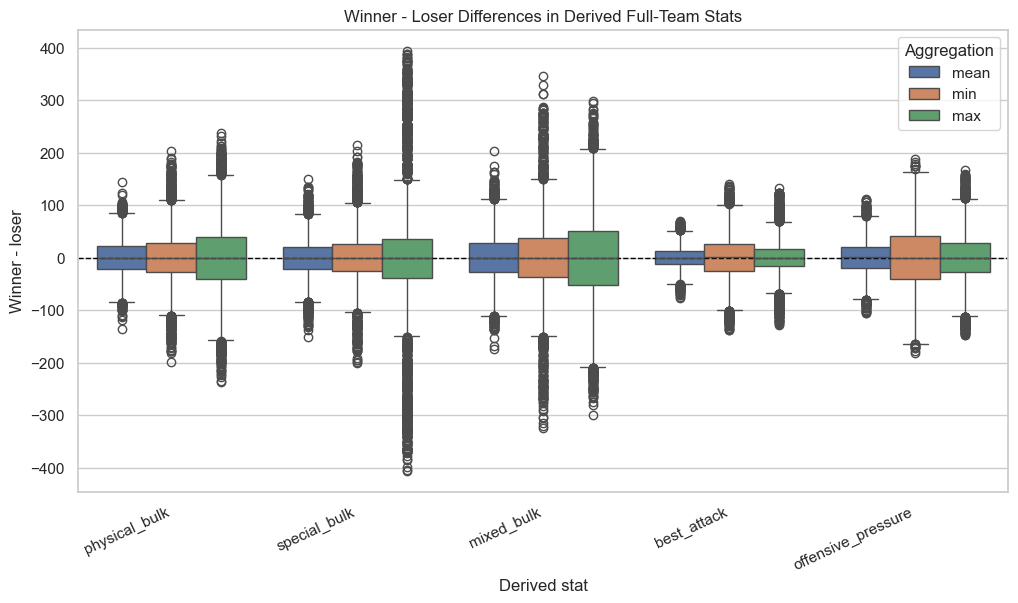

In [17]:
# Derived stat winner-minus-loser plot.

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=derived_diff_long,
    x="derived_stat",
    y="winner_minus_loser",
    hue="aggregation",
)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Winner - Loser Differences in Derived Full-Team Stats")
plt.xlabel("Derived stat")
plt.ylabel("Winner - loser")
plt.xticks(rotation=25, ha="right")
plt.legend(title="Aggregation")
plt.show()

## 2. First Pokemon Advantage EDA

### Research Question

-

### Features Looking Into And Methods

Focus: Relation between win rates and advantage of first pokemon.

-

### Main Findings

-

In [18]:
# Optional: create the key summary table or plot for this section.
# Use the shared df, or load a section-specific CSV here if needed.


## 3. Active Switch Count And Win Rate EDA

### Research Question

-

### Features Looking Into And Methods

Focus: Relationship between active switches during battle and win rate.

-

### Main Findings

-

In [19]:
# Optional: create the key summary table or plot for this section.
# Use the shared df, or load a section-specific CSV here if needed.


## 4. Pokemon Advantage Stats EDA

### Research Question

-

### Features Looking Into And Methods

Focus: Pokemon advantage features and their relation to battle outcome.

-

### Main Findings

-

In [20]:
# Optional: create the key summary table or plot for this section.
# Use the shared df, or load a section-specific CSV here if needed.


# Overall Takeaways

### Research Question

What did the combined EDA work help us understand about Pokemon rand battle prediction?

-

### Main Findings

-